# **第一章：单被试数据预处理**

***

在此单被试分析篇中，按照脑电预处理流程，分为以下8个步骤：  
- **第1步: 数据读取**  
- **第2步: 滤波**  
- **第3步: 去伪迹**  
- **第4步: 重参考**  
- **第5步: 数据分段**  
- **第6步: 叠加平均**  
- **第7步: 时频分析**
- **第8步: 数据提取**


# 第一步 - 数据读取

### 导入原始数据

由于大多数小伙伴熟悉的脑电数据处理工具包为基于MATLAB的EEGLAB  
这里使用的数据为MATLAB经典脑电数据处理工具包EEGLAB中的经典数据"eeglab_data.set"

In [ ]:
#!pip install mne

import numpy as np
import mne
import os
import gdown
import zipfile
from mne.preprocessing import ICA
from mne.time_frequency import tfr_morlet
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
plt.rcParams["figure.dpi"] = 150

%matplotlib inline

# Create a directory to store the data
data_dir = "data/"
if not os.path.exists(data_dir):
  os.makedirs(data_dir)

# 从Google Drive下载
url = "https://drive.google.com/file/d/1bXD-_dDnH5Mv3DQrV7V9fYM4-xYsZ0DN/view?usp=sharing"
filename = "sample_data"
filepath = data_dir + filename + ".zip"

# 下载数据
gdown.download(url=url, output=filepath, quiet=False, fuzzy=True)
print("Download completes!")
# 数据解压
with zipfile.ZipFile(filepath, 'r') as zip:
    zip.extractall(data_dir)
print("Unzip completes!")

# 也可以通过百度网盘下载
# 链接:https://pan.baidu.com/s/1nQgoxeWoelDyIPduFES7YA  密码:fn96
# 下载后解压，并移动到data文件夹下

data_path = data_dir + 'sample_data/eeglab_data.set'

# 也可以直接使用你自己EEGLAB文件夹内的sample data文件夹下的数据
# data_path = "/Users/zitonglu/Desktop/EEG/eeglab14_1_2b/sample_data/eeglab_data.set"

# MNE-Python中对多种格式的脑电数据都进行了支持：
# *** 如数据后缀为.set (来自EEGLAB的数据)
#     使用mne.io.read_raw_eeglab()
# *** 如数据后缀为.vhdr (BrainVision系统)
#     使用mne.io.read_raw_brainvision()
# *** 如数据后缀为.edf
#     使用mne.io.read_raw_edf()
# *** 如数据后缀为.bdf (BioSemi放大器)
#     使用mne.io.read_raw_bdf()
# *** 如数据后缀为.gdf
#     使用mne.io.read_raw_gdf()
# *** 如数据后缀为.cnt (Neuroscan系统)
#     使用mne.io.read_raw_cnt()
# *** 如数据后缀为.egi或.mff
#     使用mne.io.read_raw_egi()
# *** 如数据后缀为.data
#     使用mne.io.read_raw_nicolet()
# *** 如数据后缀为.nxe (Nexstim eXimia系统)
#     使用mne.io.read_raw_eximia()
# *** 如数据后缀为.lay或.dat (Persyst系统)
#     使用mne.io.read_raw_persyst()
# *** 如数据后缀为.eeg (Nihon Kohden系统)
#     使用mne.io.read_raw_nihon()

# 读取数据
raw = mne.io.read_raw_eeglab(data_path, preload=True)

Downloading...
From: https://drive.google.com/uc?id=1bXD-_dDnH5Mv3DQrV7V9fYM4-xYsZ0DN
To: /Users/guoyu/Documents/Python-EEG-Handbook-CN/data/sample_data.zip
100%|██████████| 7.30M/7.30M [00:01<00:00, 4.99MB/s]

Download completes!
Unzip completes!
Reading /Users/guoyu/Documents/Python-EEG-Handbook-CN/data/sample_data/eeglab_data.fdt
Reading 0 ... 30503  =      0.000 ...   238.305 secs...


### 查看原始数据信息

In [3]:
print(raw)
print(raw.info)

<RawEEGLAB | eeglab_data.fdt, 32 x 30504 (238.3 s), ~7.5 MiB, data loaded>
<Info | 7 non-empty values
 bads: []
 ch_names: EEG 000, EEG 001, EEG 002, EEG 003, EEG 004, EEG 005, EEG 006, ...
 chs: 32 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 128.0 Hz
>


可以看到该脑电数据为32个导联，30504个时间点（采样率为128Hz，对应238.3s的长度）  
由于读取数据时preload设为True，数据读入内存中，数据大小约为7.5MB  
导联名依次为“EEG 000”, “EEG 001”, “EEG 002”, “EEG 003”等等  
高通滤波0.0Hz，低通滤波64.0Hz

### 电极定位

这里由于导联名称不是标准的名称
如果碰到类似问题，需要手动导入脑电数据的电极位置信息
在这个例子中，即需要把数据集相关的.locs文件中的信息传入这里读取的脑电数据中

In [4]:
# .locs文件地址
locs_info_path = data_dir + "sample_data/eeglab_chan32.locs"
# 读取电极位置信息
montage = mne.channels.read_custom_montage(locs_info_path)
# 读取正确的导联名称
new_chan_names = np.loadtxt(locs_info_path, dtype=str, usecols=3)
# 读取旧的导联名称
old_chan_names = raw.info["ch_names"]
# 创建字典，匹配新旧导联名称
chan_names_dict = {old_chan_names[i]:new_chan_names[i] for i in range(32)}
# 更新数据中的导联名称
raw.rename_channels(chan_names_dict)
# 传入数据的电极位置信息
raw.set_montage(montage)

<RawEEGLAB | eeglab_data.fdt, 32 x 30504 (238.3 s), ~7.5 MiB, data loaded>

当你的脑电电极位点为一些特定系统时，可以直接用mne.channels.make_standard_montage函数生成  
以标准的国际10-20系统为例，对应代码即可改为：

> montage = mne.channels.make_standard_montage("standard_1020")   

MNE中现成的其他定位系统的montage可以通过以下网址查询：   
[https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html#sphx-glr-auto-tutorials-intro-40-sensor-locations-py](https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html#sphx-glr-auto-tutorials-intro-40-sensor-locations-py)

### 设置导联类型

In [5]:
# MNE中一般默认将所有导联类型设成“eeg”
# 这里将两个“EOG”导联的类型设定为“eog”

chan_types_dict = {"EOG1":"eog", "EOG2":"eog"}
raw.set_channel_types(chan_types_dict)

<RawEEGLAB | eeglab_data.fdt, 32 x 30504 (238.3 s), ~7.5 MiB, data loaded>

### 查看修改后的数据信息

In [6]:
# 打印修改后的数据信息

print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: FPz, EOG1, F3, Fz, F4, EOG2, FC5, FC1, FC2, FC6, T7, C3, C4, Cz, ...
 chs: 30 EEG, 2 EOG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 128.0 Hz
>


### 可视化原始数据

#### 绘制原始数据波形图

Using matplotlib as 2D backend.


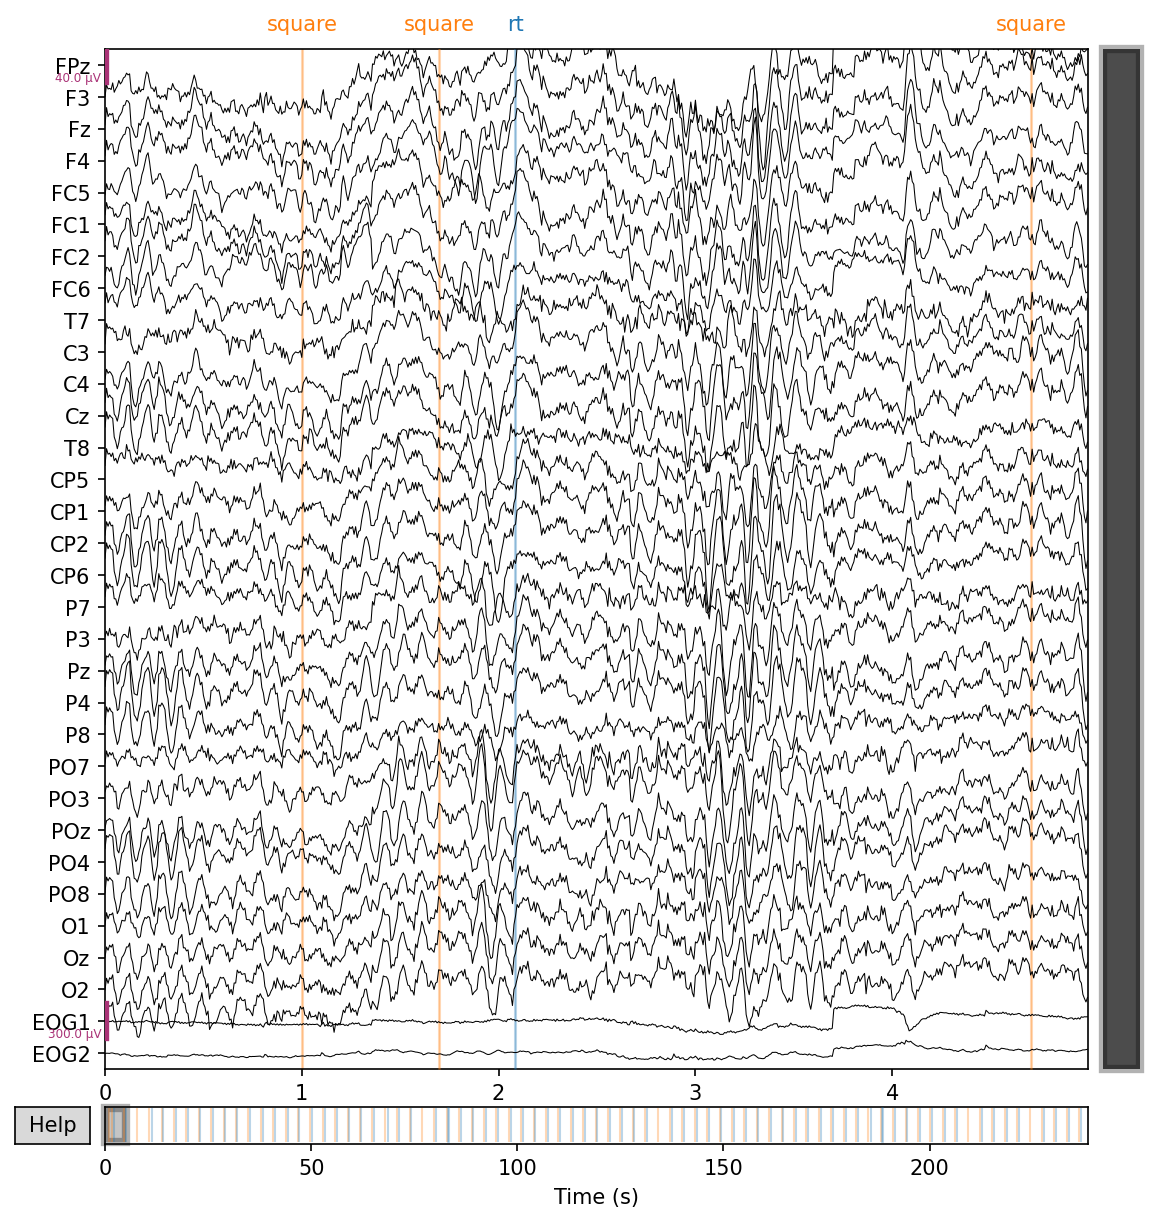

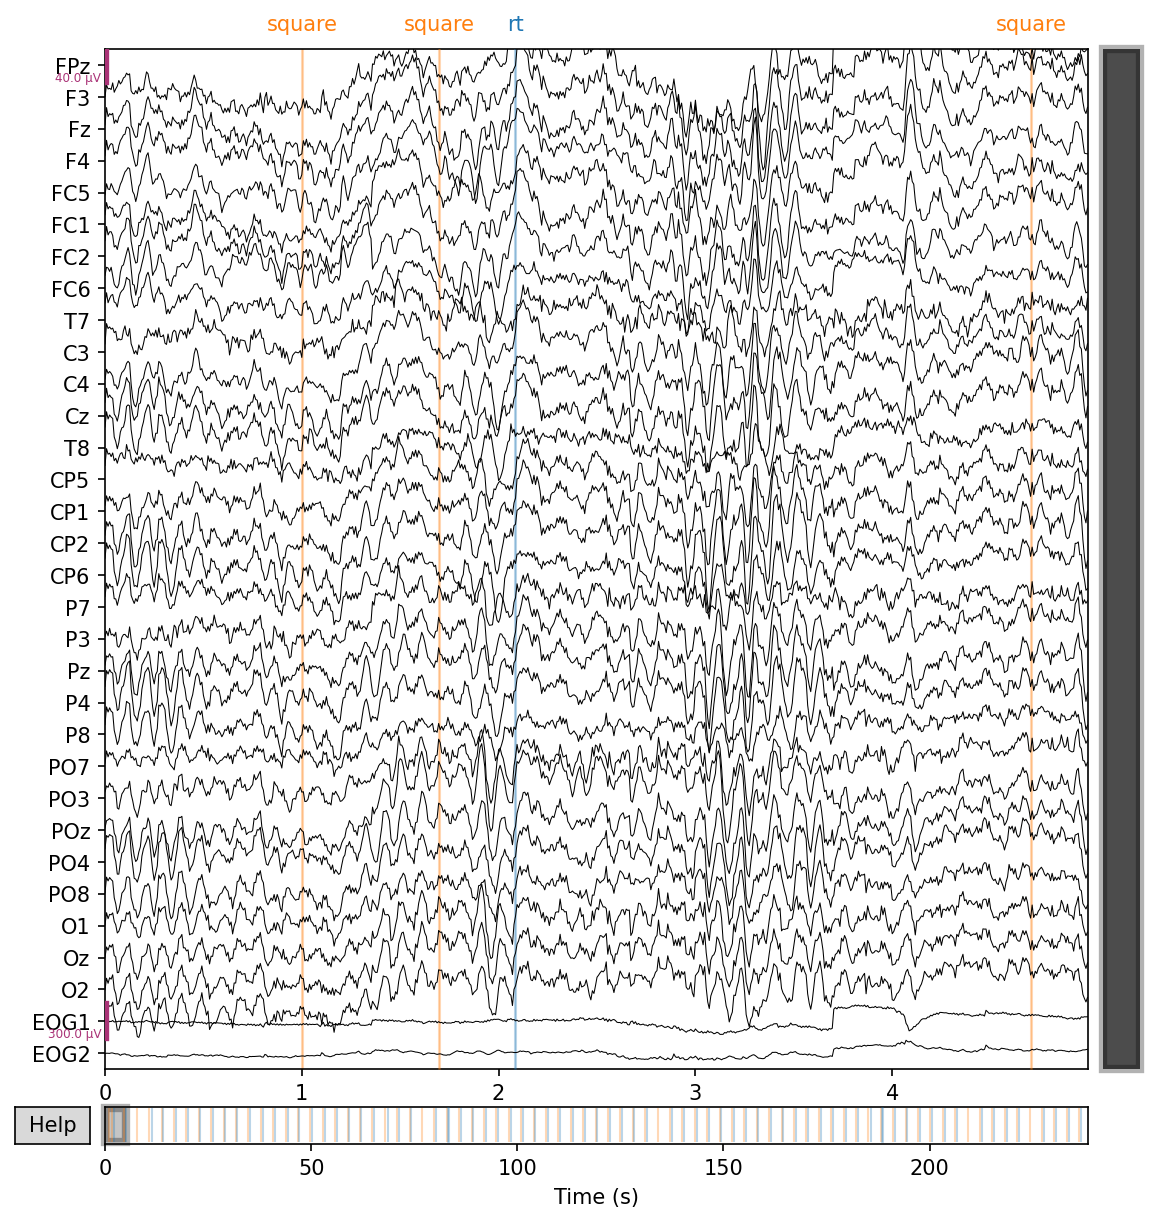

In [7]:
raw.plot(duration=5, n_channels=32, clipping=None)

#### 绘制原始数据功率谱图

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/nilearn/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


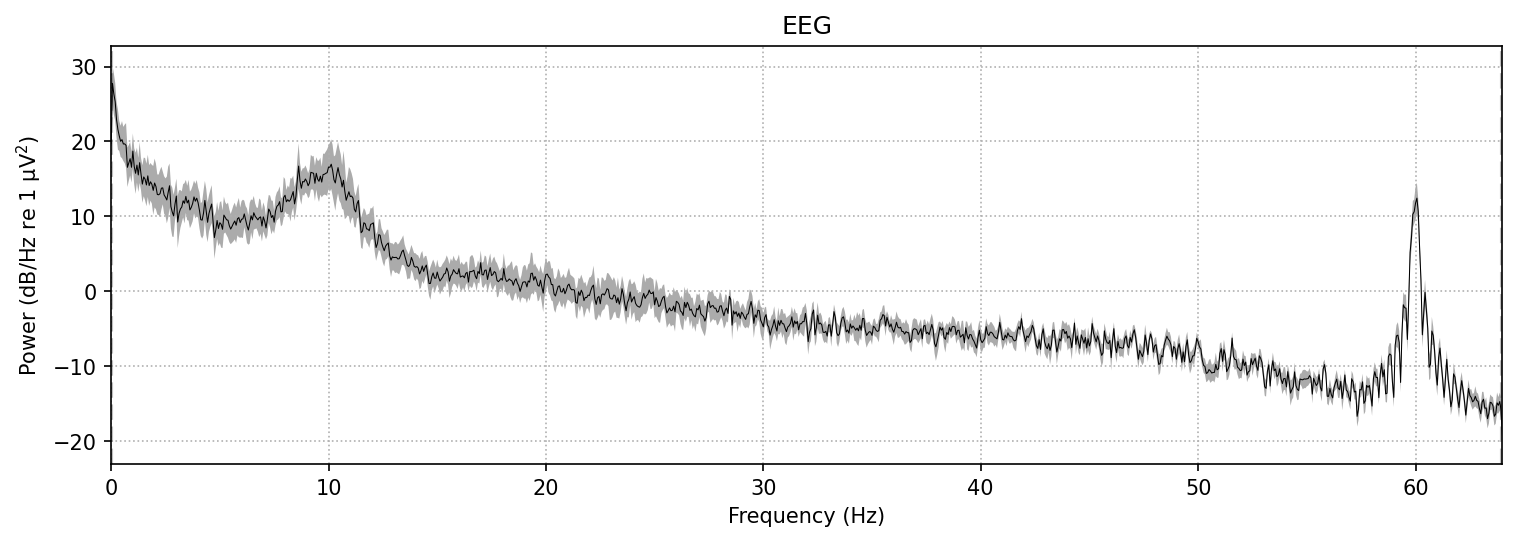

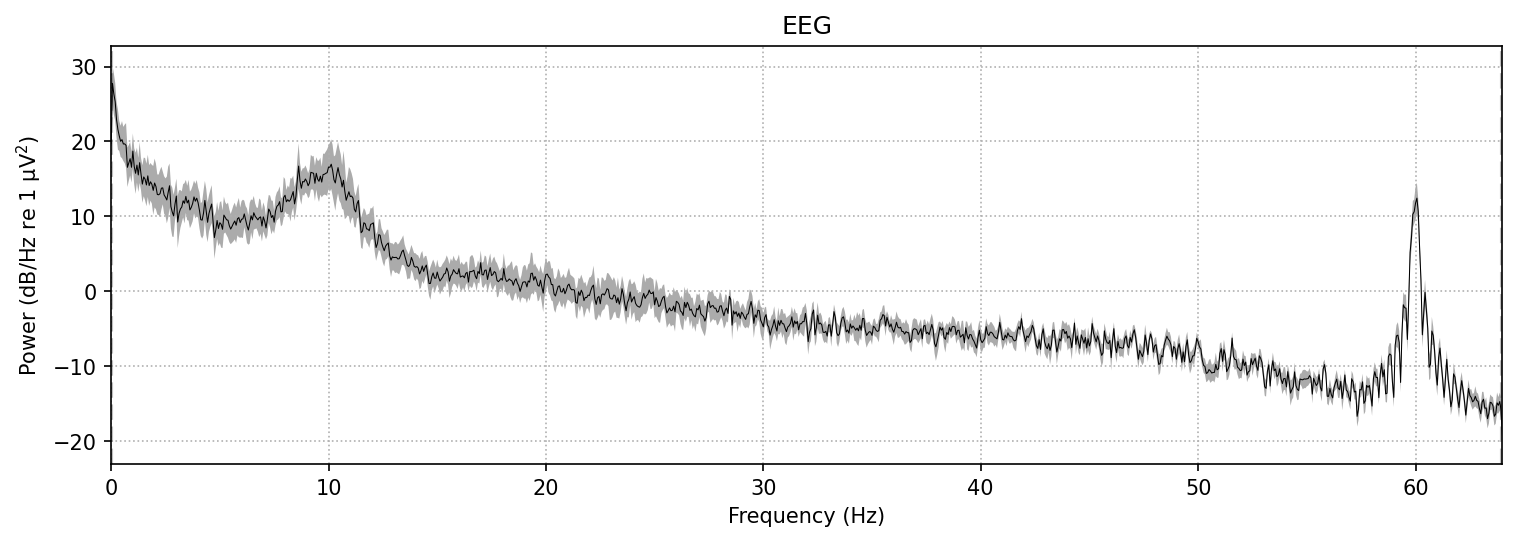

In [8]:
raw.plot_psd(average=True)

#### 绘制导联空间位置图

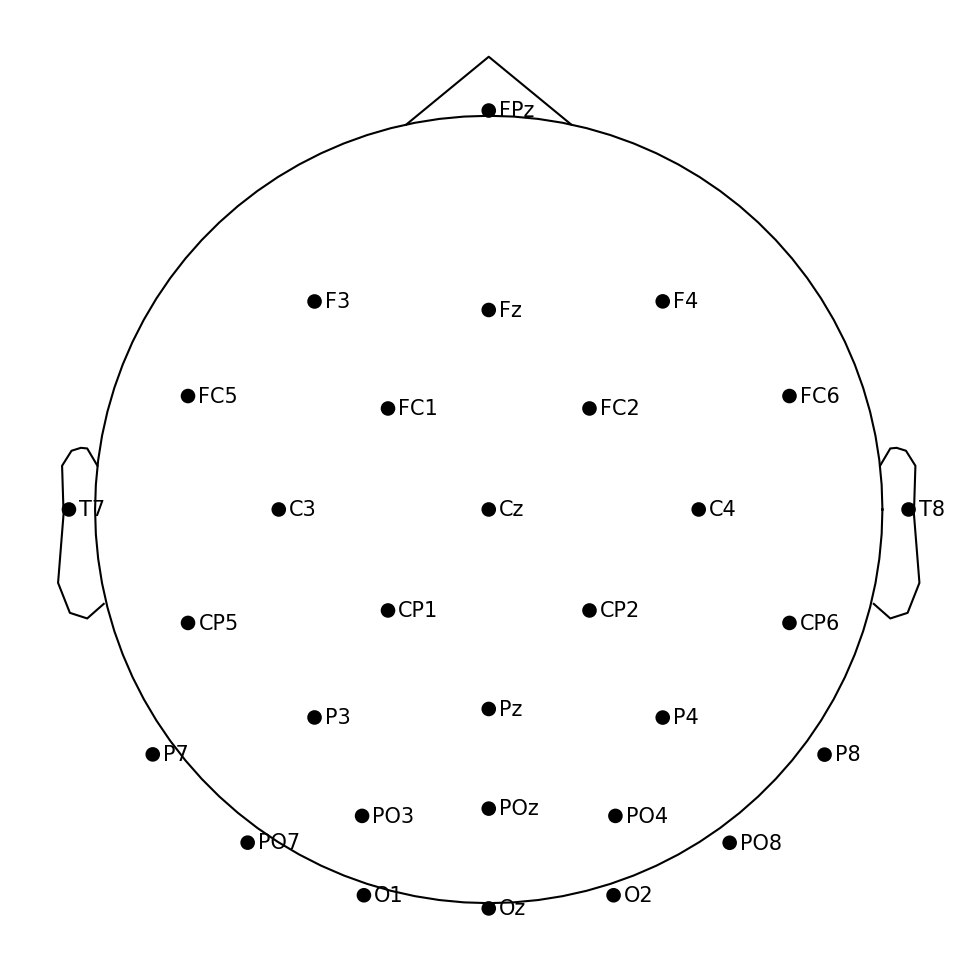

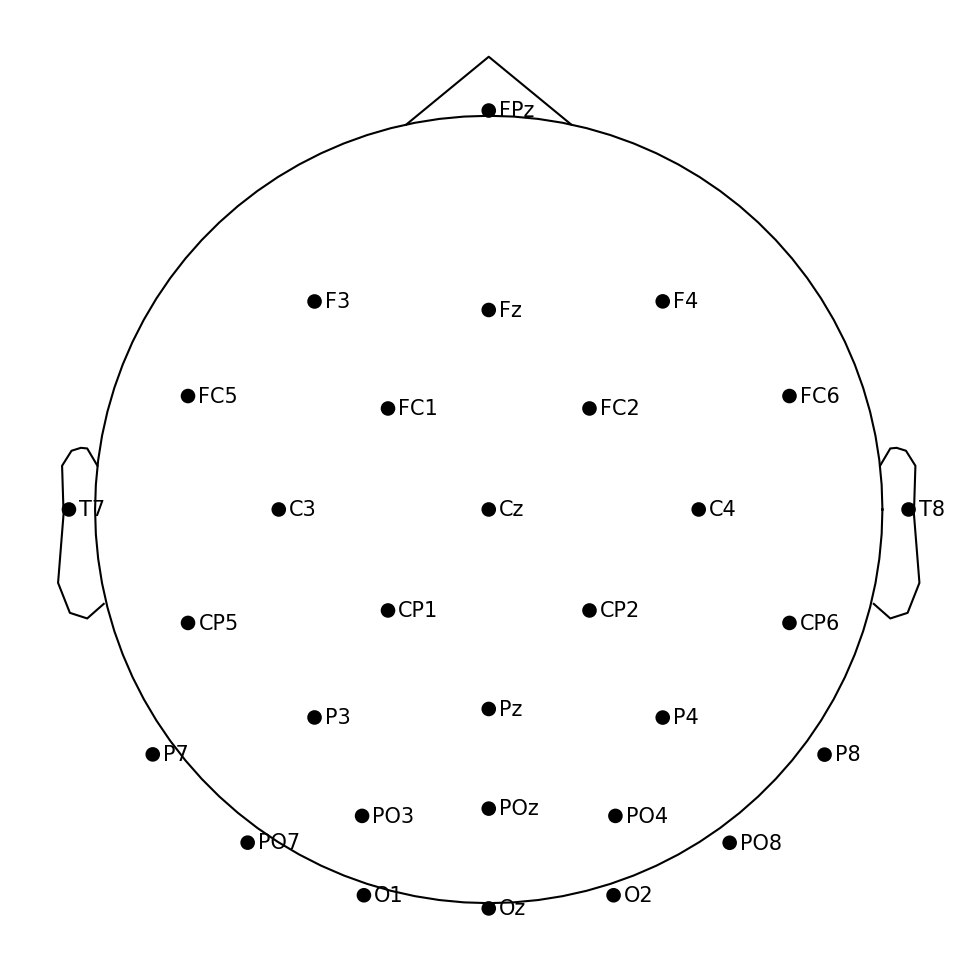

In [10]:
raw.plot_sensors(ch_type='eeg', show_names=True)

#### 绘制拓扑图形式的原始数据功率谱图

Effective window size : 16.000 (s)


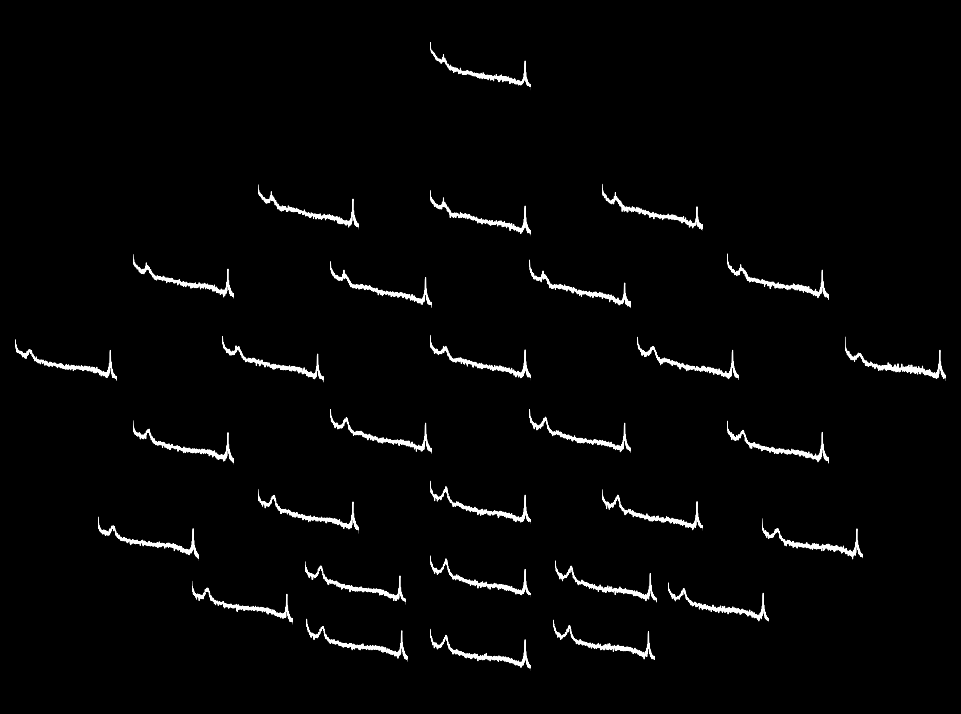

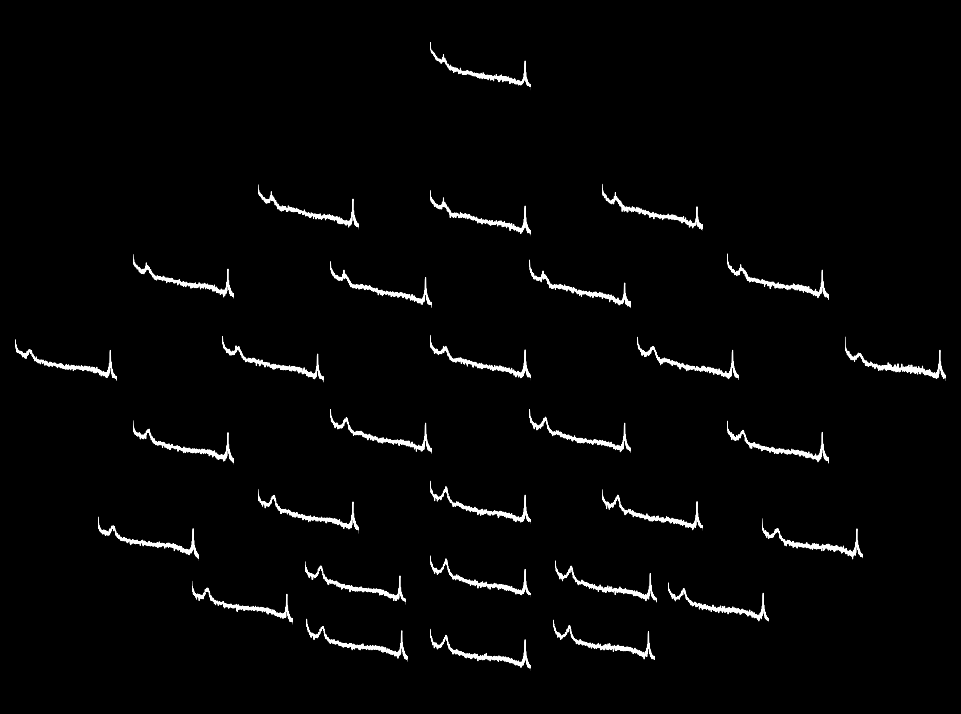

In [11]:
raw.compute_psd().plot_topo()

# 第二步 - 滤波

### 陷波滤波

通过第一步中的功率谱图可以看到60Hz处可能存在环境噪音  
这里首先使用陷波滤波器去掉工频  
注意：在中国大陆及香港澳门地区（除台湾省以外）采集的数据一般工频会出现在50Hz处  
此例比较例外，切记通过功率谱图判断

In [12]:
raw = raw.notch_filter(freqs=(60))

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 845 samples (6.602 s)



绘制功率谱图

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/nilearn/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


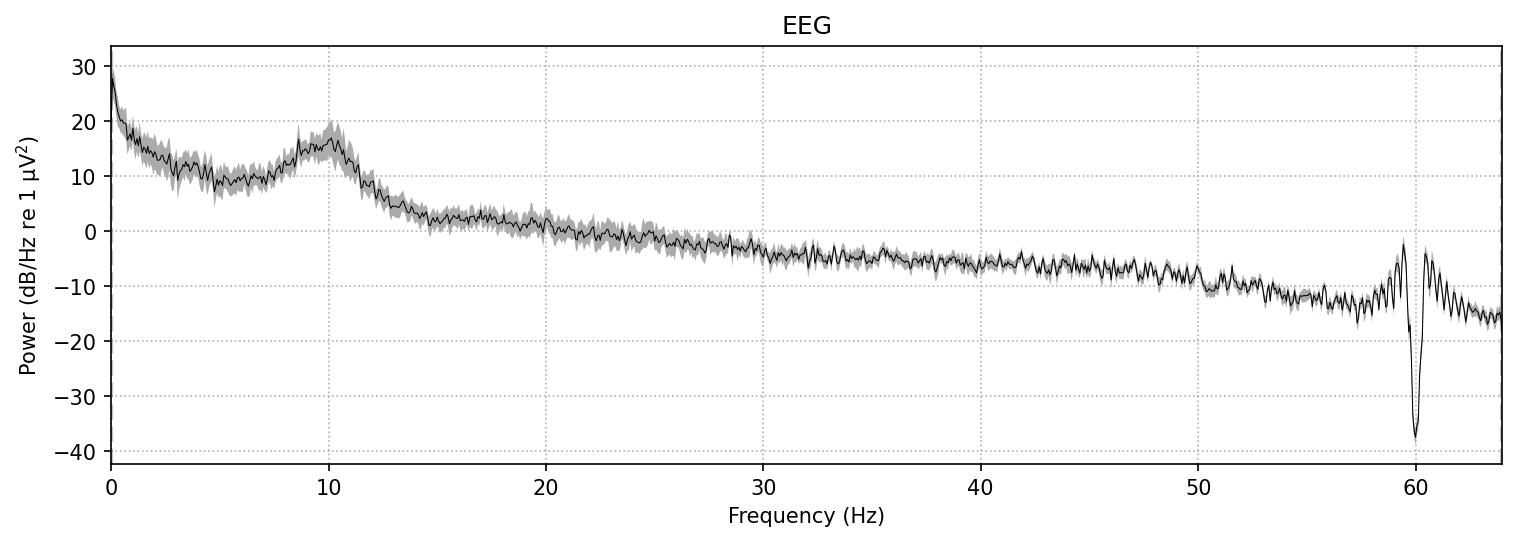

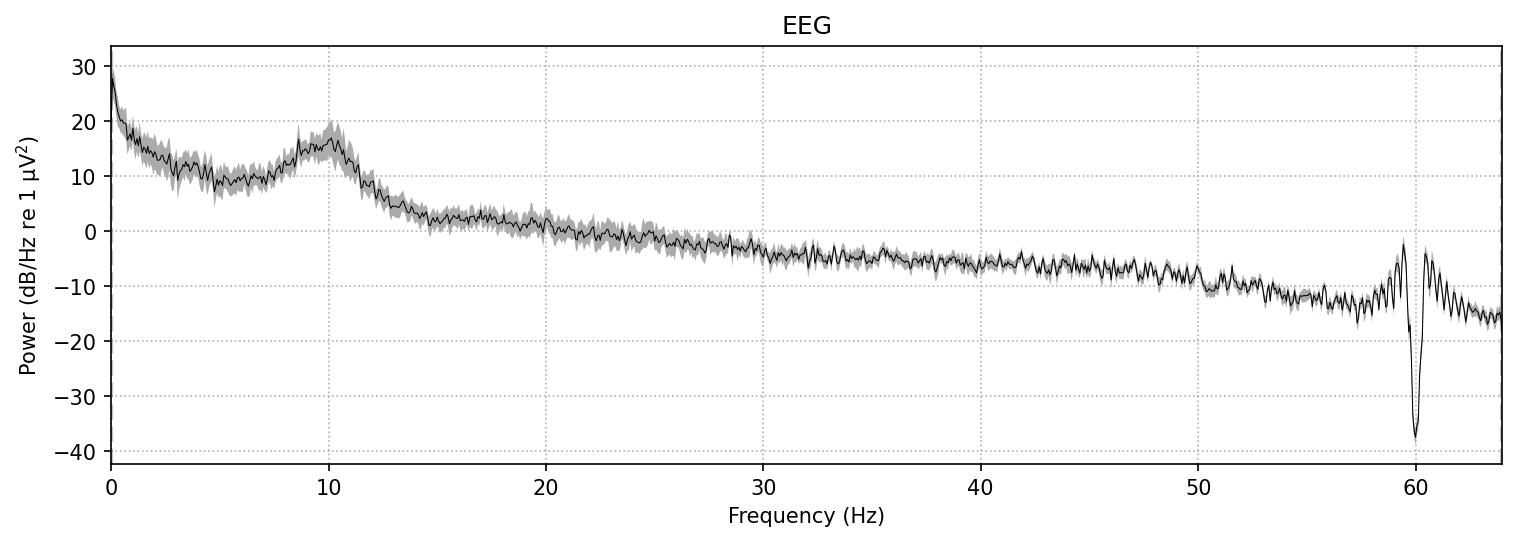

In [13]:
raw.plot_psd(average=True)

### 高/低通滤波

预处理步骤中，通常需要对数据进行高通滤波操作  
此处采用最常规的滤波操作，进行30Hz的低通滤波及0.1Hz的高通滤波  
高通滤波为了消除电压漂移，低通滤波为了消除高频噪音

In [14]:
raw = raw.filter(l_freq=0.1, h_freq=30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 4225 samples (33.008 s)



MNE中默认使用FIR滤波方法，若想使用IIR滤波方法，可通过修改参数method参数实现  
默认method='fir'，使用IIR则修改为'iir'  
对应代码即为：  

> raw = raw.filter(l_freq=0.1, h_freq=30, method='iir')

绘制功率谱图

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/nilearn/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


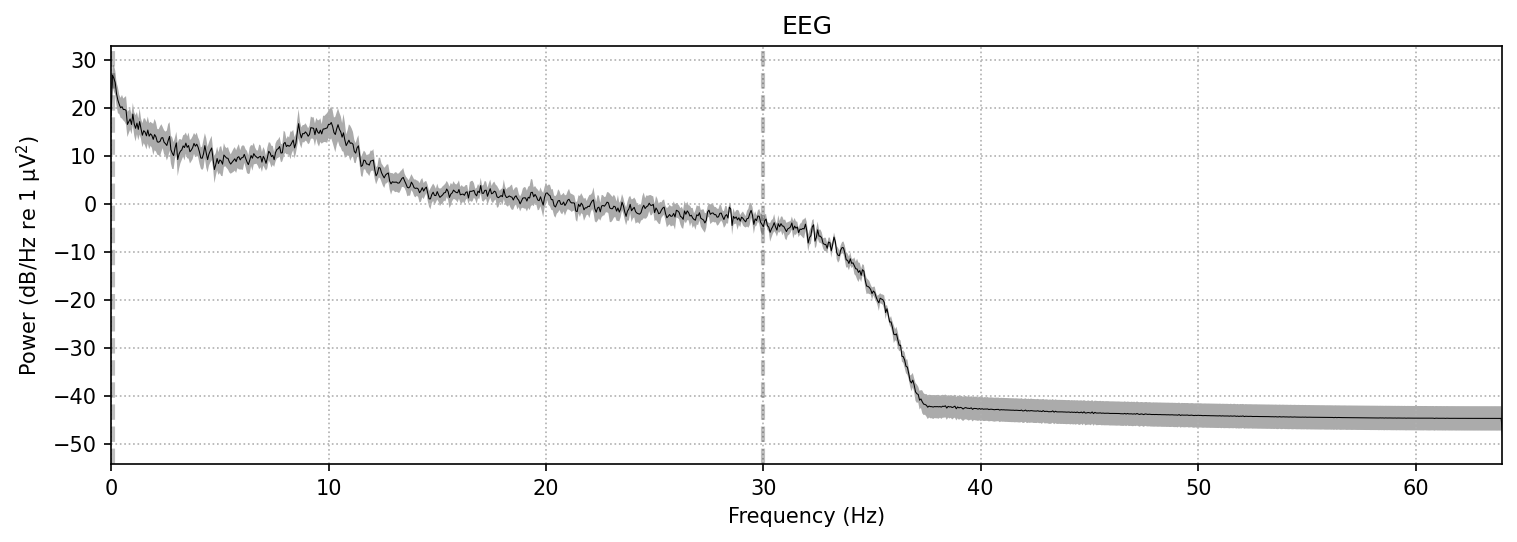

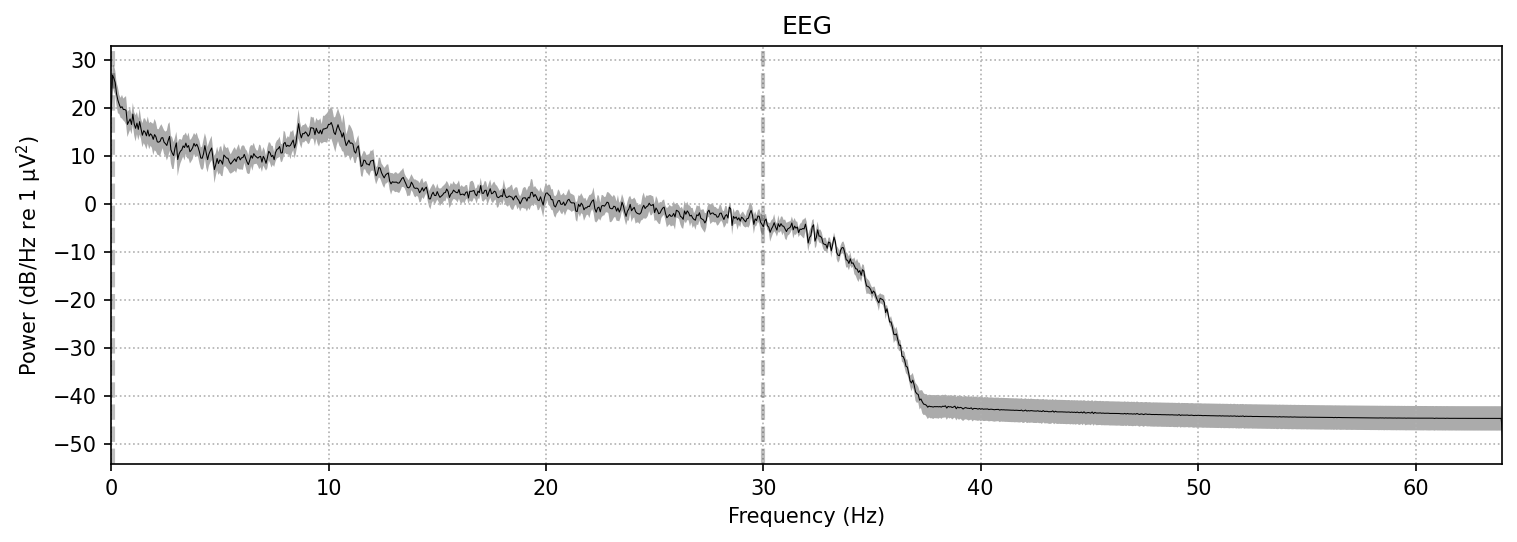

In [15]:
raw.plot_psd(average=True)

# 第三步 - 去伪迹

这里我们建议大家首先阅读下面这个来自MNE-Python官网提供的网页：  
https://mne.tools/stable/auto_tutorials/preprocessing/10_preprocessing_overview.html  
里面详细介绍了检查EEG数据质量以及各种可能遇到的噪音类型。

### 去坏段

MNE中可以通过打开交互式数据地形图界面，手动进行坏段标记

> fig = raw.plot()  
> fig.fake_keypress('a')

按a就可以打开这个GUI小窗口，add new label可以添加一个用于标记坏段的marker  
在MNE中，并不会将坏段直接删掉，而是进行了数据标记  
在之后的数据处理中，  
将进行数据处理的函数中的参数reject_by_annotation设为True即可在处理过程中自动排除标记的片段  
如果遇到GUI窗口无法弹出，需在脚本开头添加如下代码：

> import matplotlib  
> matplotlib.use('TkAgg')

**注意**：不推荐在Jupyter notebook中打开，大概率卡死

### 去坏道

MNE中坏的导联也不是直接删掉，也是通过对坏道进行'bads'标记  
在这个例子中，假定导联'FC5'为坏道，则把'FC5'进行坏道标记

In [16]:
# 标记坏道
raw.info['bads'].append('FC5')
# 打印当前坏道
print(raw.info['bads'])

['FC5']


当然，也可以添加多个坏道  
如若'FC5'和'C3'都为坏道，则通过下述代码标记：  
> raw.info['bads'].extend(['FC5', 'C3'])

### 坏道插值重构

MNE的坏道重建即是对标记为'bads'的导联进行了信号重建

In [17]:
raw = raw.interpolate_bads()

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 29 sensor positions
Interpolating 1 sensors


进行信号重建后会默认把坏掉的'bads'标记去掉  
如果不想去掉对原坏道的标记，则将reset_bads参数设为False即可，  
对应代码如下：  

> raw = raw.interpolate_bads(reset_bads=False)

### 独立成分分析 （Independent Components Analysis，ICA）

#### 运行ICA

MNE中进行ICA的编程思路是首先构建一个ICA对象（可以理解成造一个ICA分析器）  
然后用这个ICA分析器对脑电数据进行分析（通过ICA对象的一系列方法）  
由于ICA对低频分离效果不好  
这里对高通1Hz的数据进行ICA及相关成分剔除，再应用到高通0.1Hz的数据上

In [ ]:
ica = ICA(max_iter='auto')
raw_for_ica = raw.copy().filter(l_freq=1, h_freq=None)
ica.fit(raw_for_ica)

这里没有设定n_components，即ICA的成分数让MNE的ICA分析器自动去选择  
类似EEGLAB，如果希望ICA的成分数为固定个数，可以自定义设置（n_components<=n_channels）  
以30个独立成分为例，对应代码改为如下即可：  
> ica = ICA(n_components=30, max_iter='auto')

#### 绘制各独立成分的时序信号图

In [ ]:
ica.plot_sources(raw_for_ica)

#### 绘制各成分的地形图

In [ ]:
ica.plot_components()

#### 查看去掉某一或某些成分前后的信号差异

这里以去掉第2个成分（即ICA001）为例

In [ ]:
ica.plot_overlay(raw_for_ica, exclude=[1])

#### 可视化单个独立成分的信息

这里可视化第2个成分（ICA001）

In [ ]:
ica.plot_properties(raw, picks=[1])

成分ICA001的能量较高处为前额，且在低频处能量较高，在一些trials中有明显增强  
可以判断为一个眼动成分

#### 剔除成分

In [ ]:
# 设定要删除的成分序号
ica.exclude = [1]
# 应用到脑电数据上
ica.apply(raw)

绘制ICA后的数据波形图

In [ ]:
raw.plot(duration=5, n_channels=32, clipping=None)

# 第四步 - 重参考

若数据需要进行参考，以'TP9'和'TP10'为参考电极为例，可以使用以下代码：  

> raw.set_eeg_reference(ref_channels=['TP9','TP10'])  

若使用平均参考，则使用以下代码：  

> raw.set_eeg_reference(ref_channels='average')  

若使用REST参考，则使用以下代码：  
这里需要传入一个forward参数，详情可参考MNE对应介绍：  
[https://mne.tools/stable/auto_tutorials/preprocessing/55_setting_eeg_reference.html](https://mne.tools/stable/auto_tutorials/preprocessing/55_setting_eeg_reference.html)
> raw.set_eeg_reference(ref_channels='REST', forward=forward)  

若使用双极参考，则使用以下代码： (这里'EEG X'和'EEG Y'分别对应用于参考的阳极和阴极导联)  

> raw_bip_ref = mne.set_bipolar_reference(raw, anode=['EEG X'], cathode=['EEG Y'])

# 第五步 - 数据分段

### 提取事件信息

首先，需要确定分段需要用到的markers  
查看数据中的markers：

In [ ]:
print(raw.annotations)

即数据中包含两种markers，分别为'square'和'rt'  

MNE有两种数据结构存储事件信息，分别为Events和Annotations  

对于Annotations对象，其用字符串来表示时间类型，如上打印出来的所示  
其用时间点表示时间，且包含marker的持续时长，当然瞬时marker其持续时长为0  
其内部数据表示为一个类似List的类

In [ ]:
# 基于Annotations打印数据的事件持续时长

print(raw.annotations.duration)

In [ ]:
# 基于Annotations打印数据的事件的描述信息

print(raw.annotations.description)

In [ ]:
# 基于Annotations打印数据的事件的开始时间

print(raw.annotations.onset)

而Events对象，则是数据分段需要用到的一种事件记录数据类型  
其用一个整型'Event ID'编码事件类型，以样本的形式来表示时间  
且不含有marker的持续时长，其内部数据类型为NumPy Array

### 事件信息数据类型转换

将Annotations类型的事件信息转为Events类型

In [ ]:
events, event_id = mne.events_from_annotations(raw)

‘events’为记录时间相关的矩阵，‘event_id’为不同markers对应整型的字典信息  
这里打印出events矩阵的shape和event_id

In [ ]:
print(events.shape, event_id)

即'rt' marker对应数字1，'square' marker对应数字2  
共154个markers

### 数据分段

基于Events对数据进行分段  
这里提取刺激前1秒到刺激后2秒的数据，即'square' marker对应-1s到2s的数据  
取baseline时间区间为刺激前0.5s到刺激出现  
并进行卡阈值，即在epoch中出现最大幅值与最小幅值的差大于2×$10^{-4}$则该epoch被剔除  
**注意**：这里的阈值设置较大，一般数据质量佳的情况下推荐设置为5×$10^{-5}$到1×$10^{-4}$之间

In [ ]:
epochs = mne.Epochs(raw, events, event_id=2, tmin=-1, tmax=2, baseline=(-0.5, 0),
                    preload=True, reject=dict(eeg=2e-4))

即分段后的数据存为了Epochs类的对象epochs  
打印epochs即可看到分段后数据的相关信息

In [ ]:
print(epochs)

### 可视化分段后的数据

可视化分段数据（这里显示4个epochs）

In [ ]:
epochs.plot(n_epochs=4)

绘制功率谱图（逐导联）

In [ ]:
epochs.compute_psd().plot(picks='eeg')

#### 绘制功率谱拓扑图（分Theta、Alpha和Beta频段）

In [ ]:
bands = [(4, 8, 'Theta'), (8, 12, 'Alpha'), (12, 30, 'Beta')]
epochs.plot_psd_topomap(bands=bands, vlim='joint')

# 第六步 - 叠加平均

MNE中使用Epochs类来存储分段数据，用Evoked类来存储叠加平均数据

### 数据叠加平均

In [ ]:
evoked = epochs.average()

### 可视化叠加平均后的数据

#### 绘制逐导联的时序信号图

In [ ]:
evoked.plot()

#### 绘制地形图

In [ ]:
# 绘制0ms、0.5s、1s、1.5s和2s处的地形图
times = np.linspace(0, 2, 5)
evoked.plot_topomap(times=times, colorbar=True)

In [ ]:
# 绘制某一特定时刻的地形图
# 此例绘制0.8s处，取0.75-0.85s的均值

evoked.plot_topomap(times=0.8, average=0.1)

#### 绘制联合图

In [ ]:
evoked.plot_joint()

#### 绘制逐导联热力图

In [ ]:
evoked.plot_image()

#### 绘制拓扑时序信号图

In [ ]:
evoked.plot_topo()

#### 绘制平均所有电极后的ERP

In [ ]:
mne.viz.plot_compare_evokeds(evokeds=evoked, combine='mean')

绘制枕叶电极的平均ERP

In [ ]:
mne.viz.plot_compare_evokeds(evokeds=evoked, picks=['O1', 'Oz', 'O2'], combine='mean')

# 第七步 - 时频分析

MNE提供了三种时频分析计算方法，分别是：  
- Morlet wavelets，对应mne.time_frequency.tfr_morlet()
- DPSS tapers，对应mne.time_frequency.tfr_multitaper()
- Stockwell Transform，对应mne.time_frequency.tfr_stockwell()

这里，使用第一种方法为例

### 时频分析

#### 计算能量（Power）与试次间耦合（inter-trial coherence，ITC）

In [ ]:
# 设定一些时频分析的参数
# 频段选取4-30Hz

freqs = np.logspace(*np.log10([4, 30]), num=10)
n_cycles = freqs / 2.
power, itc = tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, use_fft=True)

返回的power即为能量结果，itc即为试次间耦合结果  
MNE中时频分析默认返回试次平均后的结果  
如果想获取每个试次单独的时频分析结果，将average参数设为False即可  
对应代码进行如下修改即可：  
> power, itc = tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, use_fft=True, average=False)

### 绘制时频结果

MNE的时频绘图方法里可以进行多种baseline矫正方法的选择  
其对应参数为mode，包括以下一些选择：  

- 'mean'，减去baseline均值
- 'ratio'，除以baseline均值
- 'logratio'，除以baseline均值并取log
- 'percent'，减去baseline均值并除以baseline均值
- 'zscore'，减去baseline均值再除以baseline标准差
- 'zlogratio'，除以baseline均值并取log再除以baseline取log后的标准差

下例中选择logratio的方法进行基线校正

#### 绘制枕叶导联的power结果

In [ ]:
power.plot(picks=['O1', 'Oz', 'O2'], baseline=(-0.5, 0), mode='logratio', title='auto')

#### 绘制枕叶导联的平均power结果

In [ ]:
power.plot(picks=['O1', 'Oz', 'O2'], baseline=(-0.5, 0), mode='logratio',
           title='Occipital', combine='mean')

#### 绘制power拓扑图

In [ ]:
power.plot_topo(baseline=(-0.5, 0), mode='logratio', title='Average power')

#### 绘制不同频率的power拓扑图

In [ ]:
# 以theta power和alpha power为例
# 取0-0.5s的结果

power.plot_topomap(tmin=0, tmax=0.5, fmin=4, fmax=8,
                   baseline=(-0.5, 0), mode='logratio')
power.plot_topomap(tmin=0, tmax=0.5, fmin=8, fmax=12,
                   baseline=(-0.5, 0), mode='logratio')

#### 绘制联合图

In [ ]:
# 取-0.5s至1.5s的结果
# 并绘制0.5s时10Hz左右的结果和1s时8Hz左右的结果

power.plot_joint(baseline=(-0.5, 0), mode='mean', tmin=-0.5, tmax=1.5,
                 timefreqs=[(0.5, 10), (1, 8)])

ITC结果的绘制是类似的，下面以拓扑图为例

In [ ]:
itc.plot_topo(baseline=(-0.5, 0), mode='logratio', title='Average Inter-Trial coherence')

# 第八步 - 数据提取

在进行相关计算后，往往希望能提取原始数据矩阵、分段数据矩阵、时频结果矩阵等等  
MNE中，Raw类（原始数据类型）、Epochs类（分段后数据类型）和Evocked类（叠加平均后数据类型）提供了get_data()方法  
AverageTFR类（时频分析后数据类型）提供了.data属性

### 使用"get_data()"函数

以epochs为例：

In [ ]:
epochs_array = epochs.get_data()

检查数据：

In [ ]:
print(epochs_array.shape)
print(epochs_array)

即获取了NumPy Array形式的分段数据  
其shape为[80, 32, 385]  
分别对应80个试次，32个导联和385个时间点

若想获取eog外的导联数据，则可将上述代码改为：  

> epochs_array = epochs.get_data(picks=['eeg'])

### 使用".data"方法

In [ ]:
power_array = power.data

检查数据：

In [ ]:
print(power_array.shape)
print(power_array)

即获取了NumPy Array形式的时频power结果  
其shape为[30, 10, 385]  
分别对应30个导联，10个频率和385个时间点